<a href="https://colab.research.google.com/github/Dilan-Holguin/ModeloPredictivo-AmesHousing/blob/feature%2Fanalisis-exp/fase-1/EDAnotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1 – Modelo Predictivo: Precio de Vivienda (Ames Housing)
**Proyecto Integrador – Modelos y Simulación de Sistemas I**

Integrantes: Dilan Holguin Mazo, Santiago Duarte Triana, Santiago Rendón Rivera

## 1. Introducción
Este proyecto busca predecir el precio de venta (SalePrice) de viviendas residenciales en Ames, Iowa, a partir de sus características físicas, de calidad y de ubicación. Es un problema de regresión sobre datos de corte transversal, cada fila es una vivienda vendida, sin componente temporal entre observaciones. Los datos provienen de la competencia de Kaggle "House Prices: Advanced Regression Techniques".
- **Problema:** predecir `SalePrice` (precio de venta de una vivienda).
- **Tipo de problema:** regresión, datos de corte transversal.
- **Fuente:** [Kaggle – House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)
- **Objetivo del modelo:** que sea capaz de estimar el precio de venta de una vivienda residencial a partir de sus características objetivas con el fin de ofrecer un punto de ref objetivo tanto para compradores y vendedores al momento de evaluar el precio de venta de una casa.

## 2. Descripción del conjunto de datos

In [ ]:
!git clone https://github.com/Dilan-Holguin/ModeloPredictivo-AmesHousing

Cloning into 'ModeloPredictivo-AmesHousing'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 13 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 94.72 KiB | 1.08 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
%cd ModeloPredictivo-AmesHousing

/content/ModeloPredictivo-AmesHousing/ModeloPredictivo-AmesHousing


In [ ]:
!git checkout develop
!git pull

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
!ls

fase-1	README.md


In [ ]:
#se carga el dataset COMPLETO (79 columnas)
df = pd.read_csv('fase-1/train.csv')
df.shape

(1460, 81)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.dtypes.value_counts()  # cuántas columnas numéricas vs. categóricas

,count
object,43
int64,35
float64,3


dada **la cantidad de variables categoricas** va ser necesario codificarlas antes de entrenar el modelo, ya que los algoritmos de machine learning solo operan valores numericos, y debemos clasificarlas en nominales u ordinales para saber que tipo de codificacion utilizar

## 3. Exploración de los datos (EDA)

> Todo este bloque se hace sobre las **79 columnas originales**,

### 3.1 Panorama general

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
...,...,...,...,...,...,...,...,...,...,...,...
MoSold,1460.0,NaN,NaN,NaN,6.321918,2.703626,1.0,5.0,6.0,8.0,12.0
YrSold,1460.0,NaN,NaN,NaN,2007.815753,1.328095,2006.0,2007.0,2008.0,2009.0,2010.0
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Valores faltantes

In [ ]:
faltantes = (df.isnull().mean() * 100).sort_values(ascending=False)
faltantes[faltantes > 0]

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


**MasVnrArea(0.55%)** cumple el requisito
hay varias columnas con muchos faltantes pero es porque en este dataset, varios NaN no son datos perdidos sino que la característica no existe en la vivienda, como lo son:
**caracteristica_ausente = **
*'PoolQC': 'No tiene piscina'
* 'MiscFeature': 'No tiene ninguna característica miscelánea'
* 'Alley': 'No tiene acceso por callejón'
* 'Fence': 'No tiene cerca'
* 'FireplaceQu': 'No tiene chimenea'
* 'GarageType': 'No tiene garaje', 'GarageYrBlt': 'No tiene garaje', 'GarageFinish': 'No tiene garaje', 'GarageQual': 'No tiene garaje', 'GarageCond': 'No tiene garaje'

* 'BsmtQual': 'No tiene sótano', 'BsmtCond': 'No tiene sótano', 'BsmtExposure': 'No tiene sótano', 'BsmtFinType1': 'No tiene sótano', 'BsmtFinType2': 'No tiene sótano'

* 'MasVnrType': 'No tiene revestimiento de mampostería (veneer)'

 **faltantes_reales** = ['LotFrontage', 'MasVnrArea', 'Electrical'] Estas sí representan información que debería existir pero no se registró


### 3.3 Estadísticas descriptivas

In [ ]:
df.describe()  # numéricas

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df['Neighborhood'].value_counts()

,count
Neighborhood,
NAmes,225
CollgCr,150
OldTown,113
Edwards,100
Somerst,86
Gilbert,79
NridgHt,77
Sawyer,74
NWAmes,73


el dataset contiene 25 barrios distintos, algunos el de mayo casas con 225 y el de menos con solo 2, puede que el modelo no aprenda nada del barrio blueste al tener solo 2 casas debido a la poca informacion, podriamos agrupar los barrios de pocas observaciones


### 3.4 Distribución de la variable objetivo (`SalePrice`)

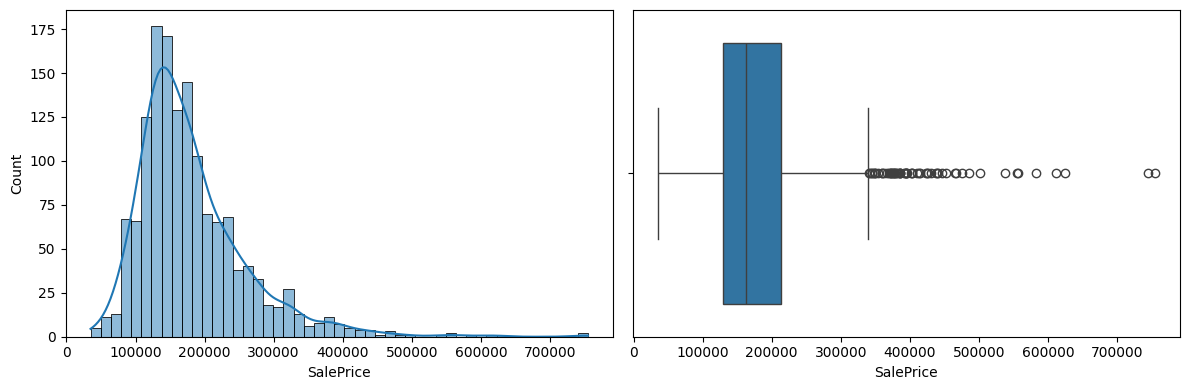

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
sns.boxplot(x=df['SalePrice'], ax=axes[1])
plt.tight_layout()
plt.show()

La distribucion de SalePrice esta sesgada a la derecha, lo que nos sugiere aplicar una transformacion logaritmica andes de entrenar el modelo

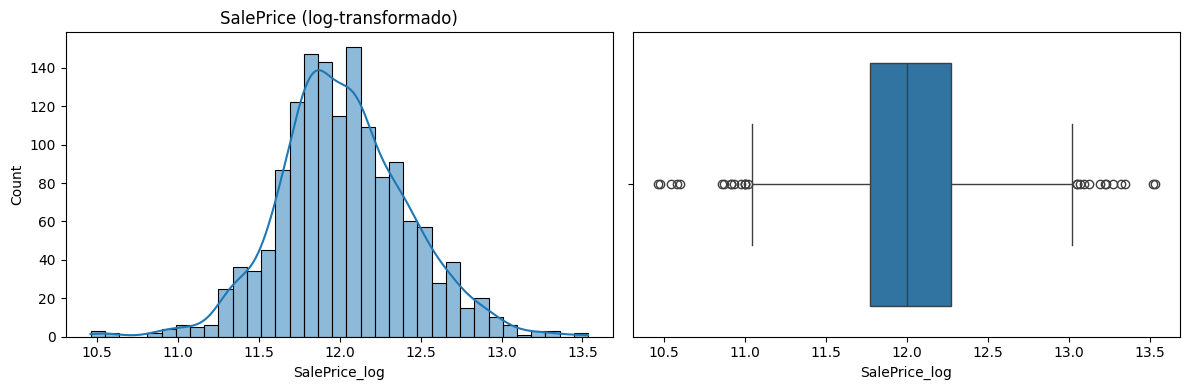

In [ ]:
import numpy as np

df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice_log'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice (log-transformado)')
sns.boxplot(x=df['SalePrice_log'], ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
La transofrmacion log ayudó a reducir la asimetria de la distribucion. asi que se entrenara el modelo con SalePrice_log en lugar de SalePrice

# Nota: al momento de evaluar o predecir
#y_pred_real = np.expm1(y_pred_log)

SyntaxError: invalid syntax (3647326880.py, line 1)

### 3.5 Relación entre predictoras y la variable objetivo

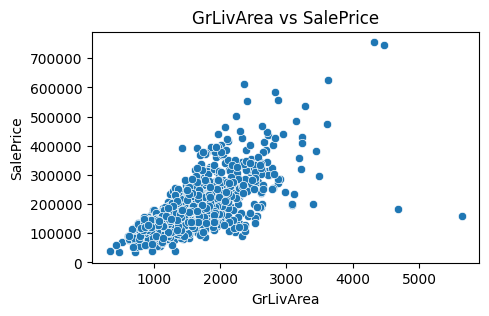

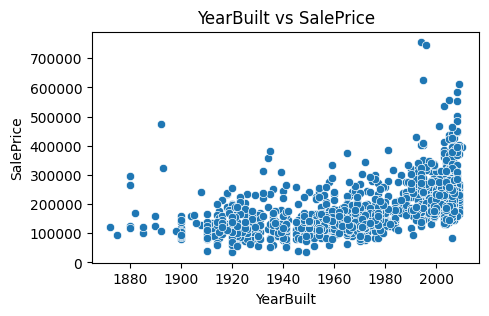

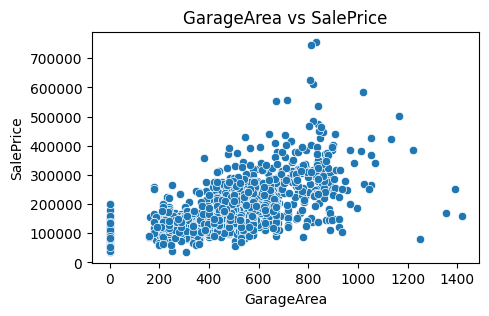

In [ ]:
# Numéricas vs. SalePrice (ejemplos, agregar las que consideren relevantes)
for col in ['GrLivArea', 'YearBuilt', 'GarageArea']:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(x=df[col], y=df['SalePrice'])
    plt.title(f'{col} vs SalePrice')
    plt.show()

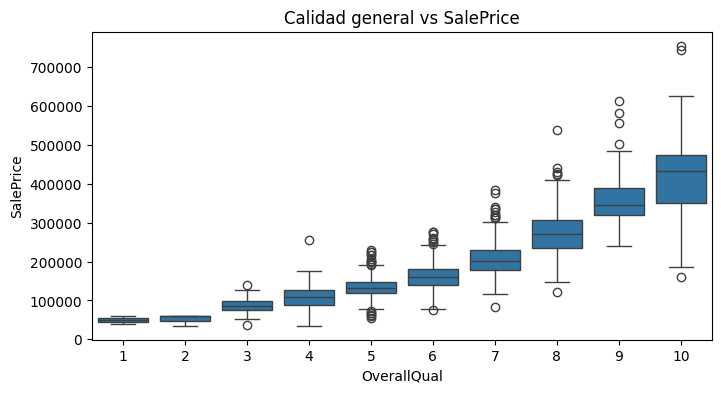

In [ ]:
# Categóricas vs. SalePrice (ejemplo)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'])
plt.title('Calidad general vs SalePrice')
plt.show()

**OverallQual y GrLivArea parecen las relaciones más fuertes → candidatas fuertes a quedarse en el modelo final.
Los outliers de GrLivArea alta con SalePrice bajo merecen mención — decidir si se eliminan o se dejan, justificando la decisión.
El grupo de GarageArea = 0 (sin garaje) confirma el patrón de faltantes que ya habían visto.**

### 3.6 Correlación entre variables numéricas

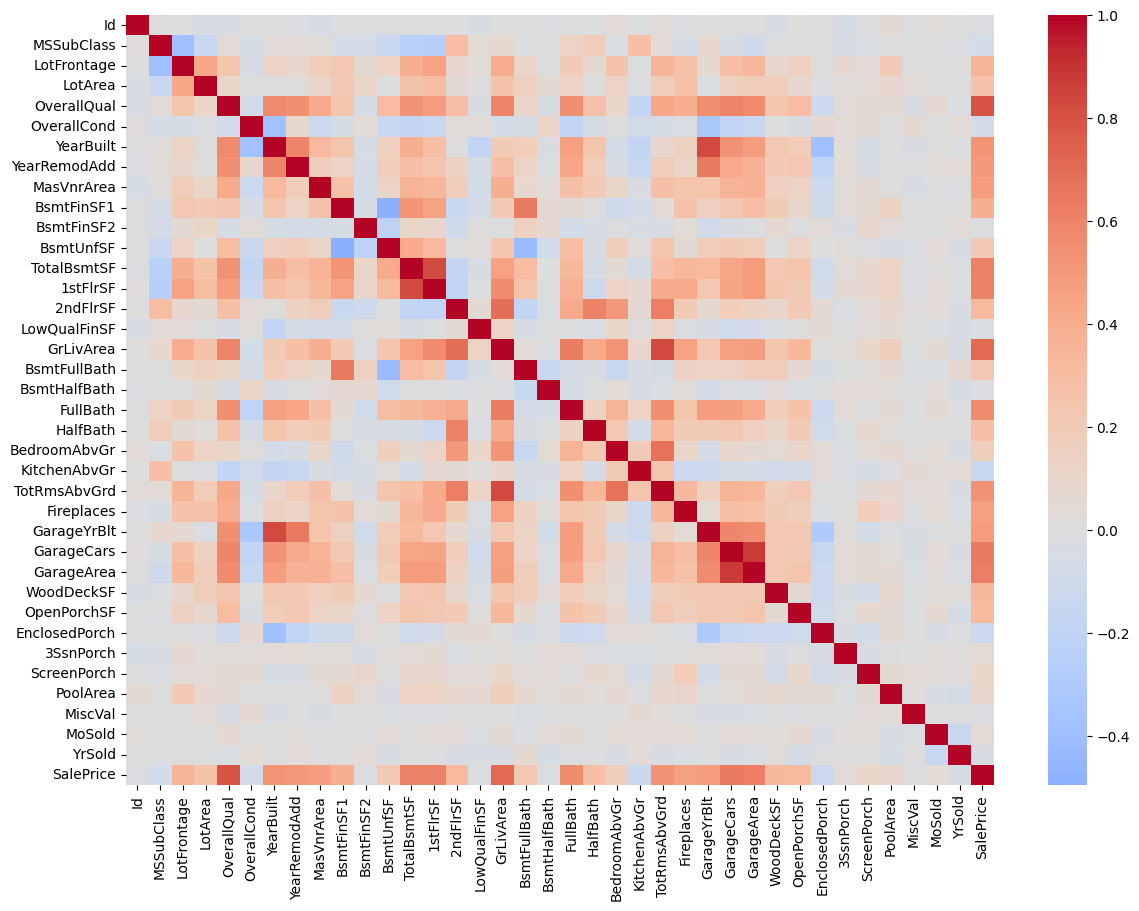

In [ ]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

In [ ]:
corr['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


Las variables con mayor correlación con SalePrice son **OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61) y 1stFlrSF (0.61).** lo que las convierte a las candidatas mas fuertes para el modelo predictivo, y a la vez vemos las variables **MoSold, 3SsnPorch, BsmtFinSF2, MiscVal, LowQualFinSF, YrSold, OverallCond, MSSubClass, EnclosedPorch y KitchenAbvGr** tienen una correlacion muy baja o negativa con SalePrice lo que nos dice que aportan poco valor predictivo.

In [ ]:
print(corr.loc['GarageCars', 'GarageArea'])
print(corr.loc['TotalBsmtSF', '1stFlrSF'])
print(corr.loc['GarageYrBlt', 'YearBuilt'])

0.882475414281462
0.8195299750050339
0.8256674841743408


Ademas identificamos estos tres pares de variables con alta correlacion entre si, lo que nos indica informacion redundante, por lo que incluir ambas variables de cada par no nos aportaria informacion adicional al modelo si no que nos podria generar multicolinealidad.

### 3.7 Variables con varianza casi nula / poco informativas

In [ ]:
#columnas donde una sola categoría domina >95% de las filas
for col in df.select_dtypes(include='object').columns:
    top_pct = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
    if top_pct > 95:
        print(f'{col}: {top_pct:.1f}% en la categoría más común')

# Columnas numéricas con exceso de ceros (>90% de las filas en 0)
numericas = df.select_dtypes(include=[np.number])

for col in numericas.columns:
    pct_cero = (numericas[col] == 0).mean() * 100
    if pct_cero > 90:
        print(f'{col}: {pct_cero:.1f}% de las filas tienen valor 0')

Street: 99.6% en la categoría más común
Utilities: 99.9% en la categoría más común
Condition2: 99.0% en la categoría más común
RoofMatl: 98.2% en la categoría más común
Heating: 97.8% en la categoría más común
PoolQC: 99.5% en la categoría más común
MiscFeature: 96.3% en la categoría más común
LowQualFinSF: 98.2% de las filas tienen valor 0
BsmtHalfBath: 94.4% de las filas tienen valor 0
3SsnPorch: 98.4% de las filas tienen valor 0
ScreenPorch: 92.1% de las filas tienen valor 0
PoolArea: 99.5% de las filas tienen valor 0
MiscVal: 96.4% de las filas tienen valor 0


  Buscamos dos tipos de columnas que casi no varian entre las viviendas, ya que si casi todas tienene el mismo valor significa que esa columna no nos ayuda mucho a predecir las diferencias de precio

  **Categoricas: Street, Utilities, Condition2, RoofMatl y Heating**
  tienen entre  97% y 99.9% de las casas con exactamente la misma categoria
  es decir, casi todas pavimentadas, mismos servicios, mismo tipo de calefaccion etc.


  **Numericas:LowQualFinSF, BsmtHalfBath, 3SsnPorch, ScreenPorch, PoolArea y MiscVal**
  estas tienen entre 92% y 99.5% de filas en 0, o sea, casi que ninguna casa tiene esa caracteristica (piscina, baño en sotano, etc.)

  Entonces estas 11 columnas son candidatas a eliminarse mas adelante ya que aportan muy poca informacion a nuestro modelo


In [ ]:
columnas_eliminar = [
    'Id',
    'Street', 'Utilities', 'Condition2', 'RoofMatl', 'Heating',
    'LowQualFinSF', 'BsmtHalfBath', '3SsnPorch', 'ScreenPorch', 'MiscVal',
    'PoolQC', 'PoolArea', 'MiscFeature',
    'GarageYrBlt',
    'Alley', 'Fence',
    'GarageArea',
]

df_seleccionado = df.drop(columns=columnas_eliminar)
df_seleccionado.shape
for col in df_seleccionado.columns:
    print(col)

MSSubClass
MSZoning
LotFrontage
LotArea
LotShape
LandContour
LotConfig
LandSlope
Neighborhood
Condition1
BldgType
HouseStyle
OverallQual
OverallCond
YearBuilt
YearRemodAdd
RoofStyle
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
HeatingQC
CentralAir
Electrical
1stFlrSF
2ndFlrSF
GrLivArea
BsmtFullBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
KitchenQual
TotRmsAbvGrd
Functional
Fireplaces
FireplaceQu
GarageType
GarageFinish
GarageCars
GarageQual
GarageCond
PavedDrive
WoodDeckSF
OpenPorchSF
EnclosedPorch
MoSold
YrSold
SaleType
SaleCondition
SalePrice


## 4. Justificación de selección de columnas

Con base en el EDA anterior, se define que:

- **Columnas que se eliminan y por qué**
1. Id
Es un identificador secuencial arbitrario (1 a 1460) sin relación con las características de la vivienda.

2. Categóricas dominadas por un solo valor: Street, Utilities, Condition2, RoofMatl, Heating
Entre 97% y 99.9% de las filas comparten la misma categoría (sección 3.7). Aportan prácticamente nula capacidad de diferenciación.

3. Numéricas con exceso de ceros y baja correlación: LowQualFinSF, BsmtHalfBath, 3SsnPorch, ScreenPorch, MiscVal
Entre 92% y 98.4% de las filas en cero, y varias con correlación casi nula con SalePrice confirmada en 3.6 (MiscVal: -0.02, 3SsnPorch: 0.04).

4. PoolQC y PoolArea (redundantes entre sí)
PoolQC (99.5% faltante) y PoolArea (99.5% en cero) representan la misma característica (piscina) medida de dos formas. Casi ninguna vivienda tiene piscina, así que se eliminan ambas versiones en vez de imputarlas.

5. MiscFeature
Es la descripción de la característica que ya se captura (de forma más útil, como número) en MiscVal, que a su vez ya se eliminó por baja variabilidad.

6. GarageYrBlt (redundante con YearBuilt)
Correlación de 0.83 con YearBuilt (sección 3.6). Se conserva YearBuilt porque tiene mayor correlación con SalePrice (0.52 vs 0.49) y no tiene valores faltantes.

7. Alley y Fence
Alley: 93.8% faltante; Fence: 80.8% faltante. A diferencia de las columnas de Garage/Bsmt (donde el patrón de faltantes es consistente y fácil de imputar como 'None'), estas dos aportan información muy escasa y de relevancia dudosa para el precio, por lo que se eliminan en vez de imputar.

8. GarageArea (redundante con GarageCars)
Correlación de 0.88 con GarageCars (sección 3.6). Se conserva GarageCars por tener ligeramente mayor correlación con SalePrice (0.64 vs 0.62).

- **Columnas que se conservan pese a tener muchos faltantes**:
FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, MasVnrType.
Estas columnas tienen NaN porque la vivienda no posee esa característica, se imputan como "None"/"No aplica" en vez de eliminarse.

- **Se Conservan con imputacion estandar (FALTANTES REALES)**¿

  *   LotFrontage: se imputará con la mediana.
  *   MasVnrArea: se imputará con la mediana (o 0).
  *   Electrical: se imputará con la moda.


- **Lista final de columnas**:
  * MSSubClass
  * MSZoning
  * LotFrontage
  * LotArea
  * LotShape
  * LandContour
  * LotConfig
  * LandSlope
  * Neighborhood
  * Condition1
  * BldgType
  * HouseStyle
  * OverallQual
  * OverallCond
  * YearBuilt
  * YearRemodAdd
  * RoofStyle
  * Exterior1st
  * Exterior2nd
  * MasVnrType
  * MasVnrArea
  * ExterQual
  * ExterCond
  * Foundation
  * BsmtQual
  * BsmtCond
  * BsmtExposure
  * BsmtFinType1
  * BsmtFinSF1
  * BsmtFinType2
  * BsmtFinSF2
  * BsmtUnfSF
  * TotalBsmtSF
  * HeatingQC
  * CentralAir
  * Electrical
  * 1stFlrSF
  * 2ndFlrSF
  * GrLivArea
  * BsmtFullBath
  * FullBath
  * HalfBath
  * BedroomAbvGr
  * KitchenAbvGr
  * KitchenQual
  * TotRmsAbvGrd
  * Functional
  * Fireplaces
  * FireplaceQu
  * GarageType
  * *GarageFinish
  * GarageCars
  * GarageQual
  * GarageCond
  * PavedDrive
  * WoodDeckSF
  * OpenPorchSF
  * EnclosedPorch
  * MoSold
  * YrSold
  * SaleType
  * SaleCondition
  * SalePrice
